# Story Deck — Chủ đề B: Cải thiện trải nghiệm khách hàng
**Dataset:** vietnam_ecommerce_2023.csv · 8.000 đơn hàng · 27 cột

**Câu hỏi trung tâm:** Đâu là điểm đau lớn nhất trong trải nghiệm mua hàng hiện tại?

---
**Narrative logic:**
1. S6 — Giao hàng trễ kéo rating xuống → xác định vấn đề cốt lõi
2. S4 — Miền Trung bị ảnh hưởng nặng nhất → zoom vào địa lý
3. S7 — Kênh nào cần đầu tư UX? → App vs Web
4. S8 — Nhóm khách giá trị cao đang bị bỏ qua → cơ hội tăng trưởng
5. Slide cuối — 3 khuyến nghị hành động cụ thể

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import seaborn as sns

# --- Cấu hình style chung ---
NAVY   = '#1A3D6B'
GREEN  = '#1D9E75'
RED    = '#C8491E'
BLUE   = '#378ADD'
GRAY   = '#B4B2A9'
AMBER  = '#BA7517'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'axes.axisbelow':    True,
    'figure.dpi':        130,
})

df = pd.read_csv('vietnam_ecommerce_2023.csv')
print(f'Dataset: {df.shape[0]:,} đơn hàng · {df.shape[1]} cột')
df.head(2)

Dataset: 8,000 đơn hàng · 27 cột


,order_id,order_date,month,quarter,day_of_week,customer_id,gender,age_group,city,region,...,discount_amount,net_value,shipping_fee,free_shipping,total_paid,delivery_days,returned,rating,campaign,profit
0,DH2023006817,2023-01-01,1,Q1,Sunday,KH00664,Nam,55+,Hà Nội,Miền Bắc,...,0,51028,25000,False,76028,2,False,5,NaN,-9692
1,DH2023002181,2023-01-01,1,Q1,Sunday,KH04895,Nam,25-34,Hà Nội,Miền Bắc,...,94948,538040,0,True,538040,1,False,5,NaN,215216


---
## Slide 1 · S6 — Giao hàng trễ kéo rating xuống: ngưỡng 4 ngày là điểm bẻ gãy

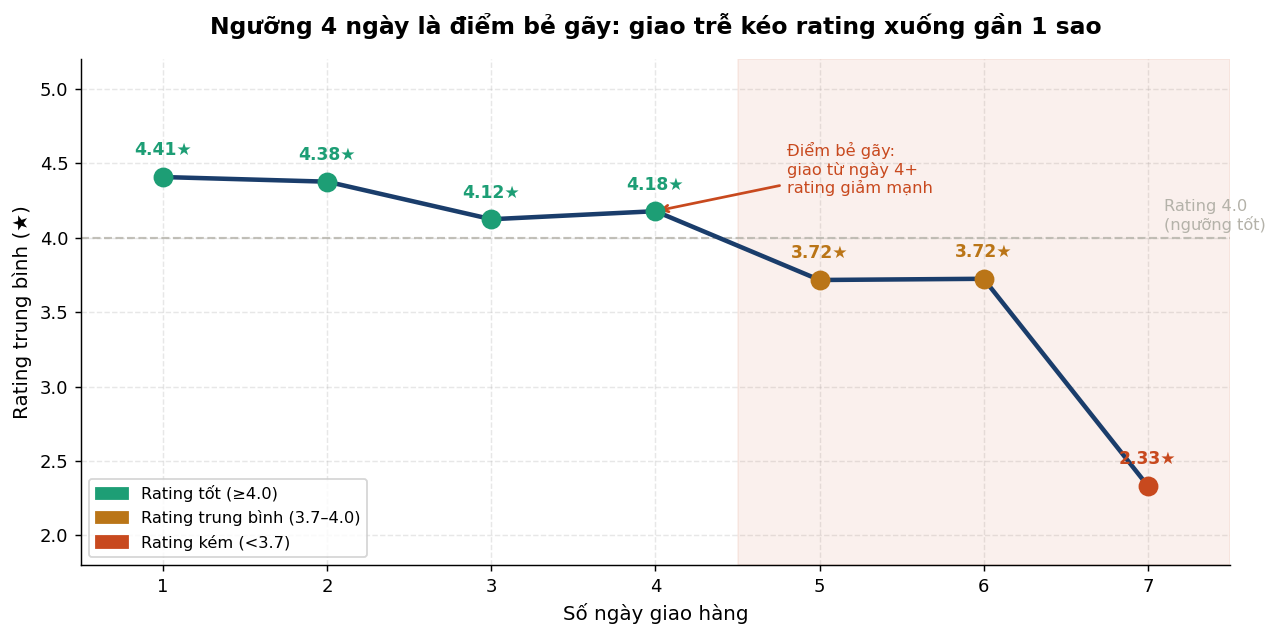


📌 Kết luận:
Cam kết SLA giao hàng ≤3 ngày là điều kiện tối thiểu để giữ rating ≥4.0.
Giao từ ngày 5 trở đi, rating rơi xuống 3.72 — mức nguy hiểm cho retention khách hàng.


In [ ]:
# --- Tính dữ liệu ---
s6 = df.groupby('delivery_days')['rating'].mean().reset_index()
s6.columns = ['delivery_days', 'avg_rating']

# --- Vẽ biểu đồ ---
fig, ax = plt.subplots(figsize=(10, 5))

# Shaded region: vùng nguy hiểm (≥5 ngày)
ax.axvspan(4.5, 7.5, alpha=0.08, color=RED, label='Vùng nguy hiểm (≥5 ngày)')

# Đường tham chiếu rating 4.0
ax.axhline(y=4.0, color=GRAY, linestyle='--', linewidth=1.2, alpha=0.8)
ax.text(7.1, 4.03, 'Rating 4.0\n(ngưỡng tốt)', fontsize=9, color=GRAY, va='bottom')

# Line chart chính
ax.plot(s6['delivery_days'], s6['avg_rating'],
        color=NAVY, linewidth=2.5, marker='o', markersize=0, zorder=3)

# Điểm màu theo ngưỡng rating
for _, row in s6.iterrows():
    d, r = row['delivery_days'], row['avg_rating']
    color = GREEN if r >= 4.0 else (AMBER if r >= 3.7 else RED)
    ax.plot(d, r, 'o', color=color, markersize=10, zorder=4)
    ax.annotate(f'{r:.2f}★',
                xy=(d, r),
                xytext=(0, 12),
                textcoords='offset points',
                ha='center', fontsize=9.5, color=color, fontweight='bold')

# Annotation điểm bẻ gãy
ax.annotate('Điểm bẻ gãy:\ngiao từ ngày 4+\nrating giảm mạnh',
            xy=(4, s6.loc[s6['delivery_days']==4, 'avg_rating'].values[0]),
            xytext=(4.8, 4.3),
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.5),
            fontsize=9, color=RED)

# Legend
patches = [
    mpatches.Patch(color=GREEN,  label='Rating tốt (≥4.0)'),
    mpatches.Patch(color=AMBER,  label='Rating trung bình (3.7–4.0)'),
    mpatches.Patch(color=RED,    label='Rating kém (<3.7)'),
]
ax.legend(handles=patches, fontsize=9, loc='lower left')

ax.set_title('Ngưỡng 4 ngày là điểm bẻ gãy: giao trễ kéo rating xuống gần 1 sao',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Số ngày giao hàng', fontsize=11)
ax.set_ylabel('Rating trung bình (★)', fontsize=11)
ax.set_xticks(s6['delivery_days'])
ax.set_ylim(1.8, 5.2)
ax.set_xlim(0.5, 7.5)

plt.tight_layout()
plt.savefig('slide1_s6_delivery_vs_rating.png', bbox_inches='tight')
plt.show()

print('\n Kết luận:')
print('Cam kết SLA giao hàng ≤3 ngày là điều kiện tối thiểu để giữ rating ≥4.0.')
print('Giao từ ngày 5 trở đi, rating rơi xuống 3.72 — mức nguy hiểm cho retention khách hàng.')

---
## Slide 2 · S4 — Miền Trung: đơn giá cao nhất nhưng giao hàng chậm gấp 1.6 lần Miền Nam

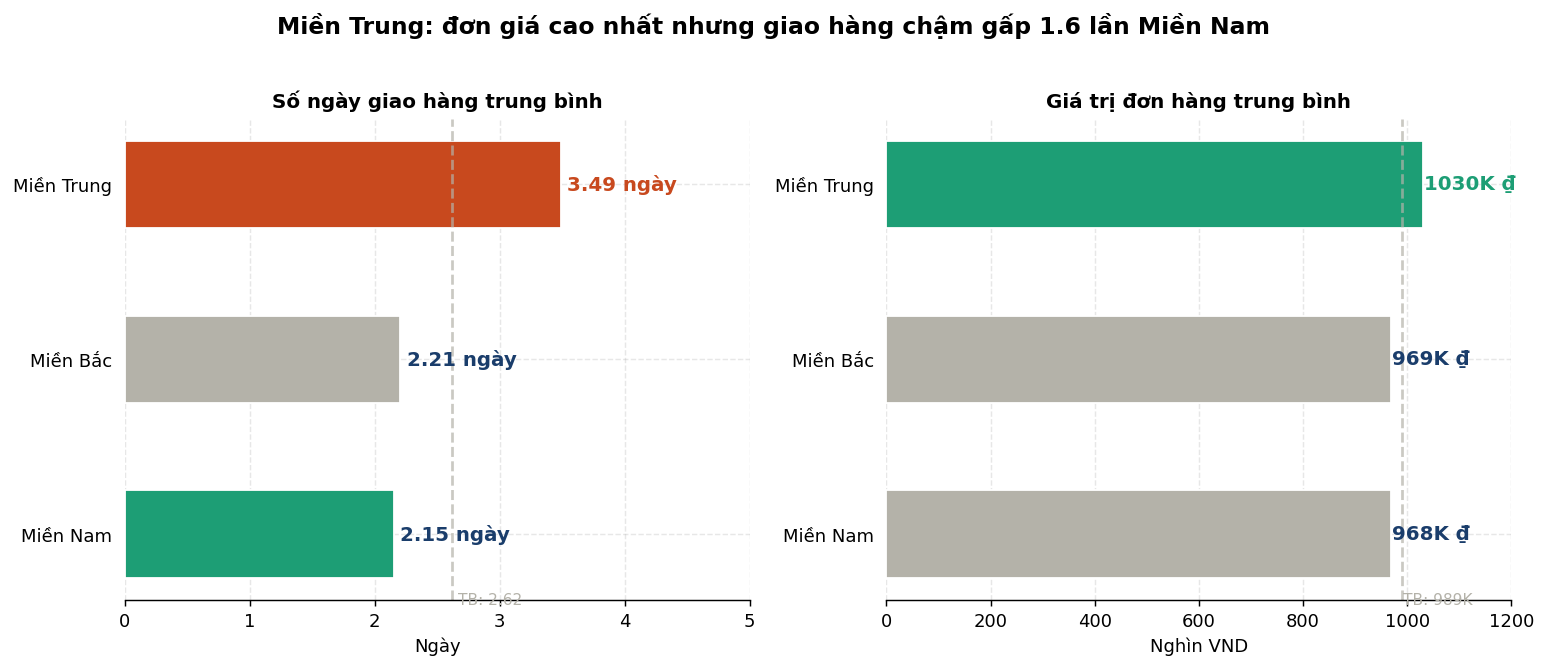


📌 Kết luận:
Miền Trung giao 3.49 ngày TB
vs Miền Nam 2.15 ngày TB
Nhưng đơn giá Miền Trung cao nhất (1.03M) — thị trường tiềm năng đang bị phục vụ kém về logistics.


In [ ]:
# --- Tính dữ liệu ---
s4 = df.groupby('region').agg(
    avg_order    = ('net_value',     'mean'),
    avg_delivery = ('delivery_days', 'mean'),
    orders       = ('order_id',      'count')
).reset_index()

# Sắp xếp theo delivery_days tăng dần để dễ so sánh
s4 = s4.sort_values('avg_delivery')

# --- Vẽ biểu đồ ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Subplot 1: Ngày giao hàng (horizontal bar) ---
ax1 = axes[0]
colors_delivery = [GREEN if r == 'Miền Nam' else (GRAY if r == 'Miền Bắc' else RED)
                   for r in s4['region']]
bars = ax1.barh(s4['region'], s4['avg_delivery'], color=colors_delivery,
                edgecolor='white', height=0.5)

for bar, val in zip(bars, s4['avg_delivery']):
    ax1.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.2f} ngày', va='center', fontsize=11,
             color=RED if val > 3 else NAVY, fontweight='bold')

ax1.axvline(x=s4['avg_delivery'].mean(), color=GRAY, linestyle='--', alpha=0.7)
ax1.text(s4['avg_delivery'].mean() + 0.05, -0.4,
         f'TB: {s4["avg_delivery"].mean():.2f}', fontsize=8.5, color=GRAY)

ax1.set_title('Số ngày giao hàng trung bình', fontsize=11, fontweight='bold')
ax1.set_xlabel('Ngày')
ax1.set_xlim(0, 5)
ax1.spines['left'].set_visible(False)
ax1.tick_params(left=False)

# --- Subplot 2: Đơn giá trung bình (horizontal bar) ---
ax2 = axes[1]
colors_order = [GREEN if r == 'Miền Trung' else GRAY for r in s4['region']]
bars2 = ax2.barh(s4['region'], s4['avg_order'] / 1000, color=colors_order,
                 edgecolor='white', height=0.5)

for bar, val in zip(bars2, s4['avg_order']):
    ax2.text(val/1000 + 2, bar.get_y() + bar.get_height()/2,
             f'{val/1000:.0f}K ₫', va='center', fontsize=11,
             color=GREEN if val > 1000000 else NAVY, fontweight='bold')

ax2.axvline(x=s4['avg_order'].mean()/1000, color=GRAY, linestyle='--', alpha=0.7)
ax2.text(s4['avg_order'].mean()/1000 + 2, -0.4,
         f'TB: {s4["avg_order"].mean()/1000:.0f}K', fontsize=8.5, color=GRAY)

ax2.set_title('Giá trị đơn hàng trung bình', fontsize=11, fontweight='bold')
ax2.set_xlabel('Nghìn VND')
ax2.set_xlim(0, 1200)
ax2.spines['left'].set_visible(False)
ax2.tick_params(left=False)

fig.suptitle('Miền Trung: đơn giá cao nhất nhưng giao hàng chậm gấp 1.6 lần Miền Nam',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('slide2_s4_region_comparison.png', bbox_inches='tight')
plt.show()

print('\n Kết luận:')
print(f'Miền Trung giao {s4.loc[s4["region"]=="Miền Trung", "avg_delivery"].values[0]:.2f} ngày TB')
print(f'vs Miền Nam {s4.loc[s4["region"]=="Miền Nam", "avg_delivery"].values[0]:.2f} ngày TB')
print('Nhưng đơn giá Miền Trung cao nhất (1.03M) — thị trường tiềm năng đang bị phục vụ kém về logistics.')

---
## Slide 3 · S7 — App chiếm 75% đơn hàng, nhưng Web có giá trị đơn cao hơn 8.7%

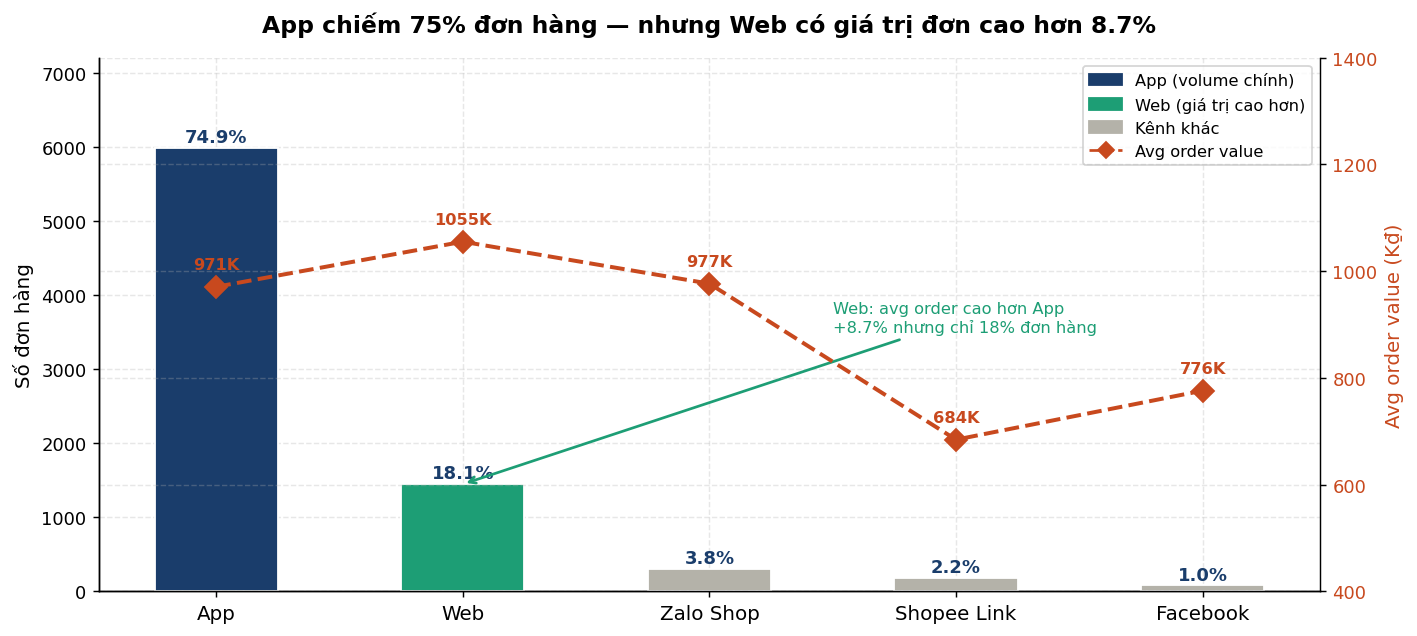


📌 Kết luận:
App avg order: 971K₫  |  Web avg order: 1055K₫  |  Chênh lệch: +8.7%
Cần tối ưu cả hai kênh theo hướng khác nhau: App → tăng avg order; Web → tăng volume.


In [ ]:
# --- Tính dữ liệu ---
s7 = df.groupby('channel').agg(
    orders        = ('order_id',   'count'),
    avg_order     = ('net_value',  'mean'),
    total_revenue = ('net_value',  'sum')
).reset_index()
s7['pct_orders'] = s7['orders'] / s7['orders'].sum() * 100
s7 = s7.sort_values('orders', ascending=False)

# --- Vẽ biểu đồ ---
fig, ax1 = plt.subplots(figsize=(11, 5))

x = np.arange(len(s7))
colors_ch = [NAVY if c == 'App' else (GREEN if c == 'Web' else GRAY)
             for c in s7['channel']]

# Bar chart: số đơn hàng
bars = ax1.bar(x, s7['orders'], color=colors_ch, width=0.5,
               edgecolor='white', zorder=3)

for bar, pct in zip(bars, s7['pct_orders']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
             f'{pct:.1f}%', ha='center', fontsize=10, color=NAVY, fontweight='bold')

ax1.set_ylabel('Số đơn hàng', fontsize=11)
ax1.set_ylim(0, 7200)
ax1.set_xticks(x)
ax1.set_xticklabels(s7['channel'], fontsize=11)

# Trục phụ: avg order value
ax2 = ax1.twinx()
ax2.plot(x, s7['avg_order'] / 1000, color=RED, marker='D',
         markersize=9, linewidth=2.2, linestyle='--', zorder=4, label='Avg order (K₫)')

for xi, val in zip(x, s7['avg_order']):
    ax2.annotate(f"{val/1000:.0f}K",
                 xy=(xi, val/1000),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=9, color=RED, fontweight='bold')

ax2.set_ylabel('Avg order value (K₫)', fontsize=11, color=RED)
ax2.tick_params(axis='y', labelcolor=RED)
ax2.set_ylim(400, 1400)
ax2.spines['right'].set_visible(True)

# Highlight App vs Web
ax1.annotate('Web: avg order cao hơn App\n+8.7% nhưng chỉ 18% đơn hàng',
             xy=(1, s7.loc[s7['channel']=='Web', 'orders'].values[0]),
             xytext=(2.5, 3500),
             arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5),
             fontsize=9, color=GREEN)

# Legend
legend_els = [
    mpatches.Patch(color=NAVY,  label='App (volume chính)'),
    mpatches.Patch(color=GREEN, label='Web (giá trị cao hơn)'),
    mpatches.Patch(color=GRAY,  label='Kênh khác'),
    plt.Line2D([0],[0], color=RED, marker='D', linestyle='--', label='Avg order value'),
]
ax1.legend(handles=legend_els, fontsize=9, loc='upper right')

ax1.set_title('App chiếm 75% đơn hàng — nhưng Web có giá trị đơn cao hơn 8.7%',
              fontsize=13, fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig('slide3_s7_channel_behavior.png', bbox_inches='tight')
plt.show()

print('\n Kết luận:')
app_avg = s7.loc[s7['channel']=='App', 'avg_order'].values[0]
web_avg = s7.loc[s7['channel']=='Web', 'avg_order'].values[0]
print(f'App avg order: {app_avg/1000:.0f}K₫  |  Web avg order: {web_avg/1000:.0f}K₫  |  Chênh lệch: +{(web_avg-app_avg)/app_avg*100:.1f}%')
print('Cần tối ưu cả hai kênh theo hướng khác nhau: App → tăng avg order; Web → tăng volume.')

---
## Slide 4 · S8 — Nam 45–54 tuổi chi tiêu cao nhất nhưng chỉ chiếm 5.8% đơn hàng

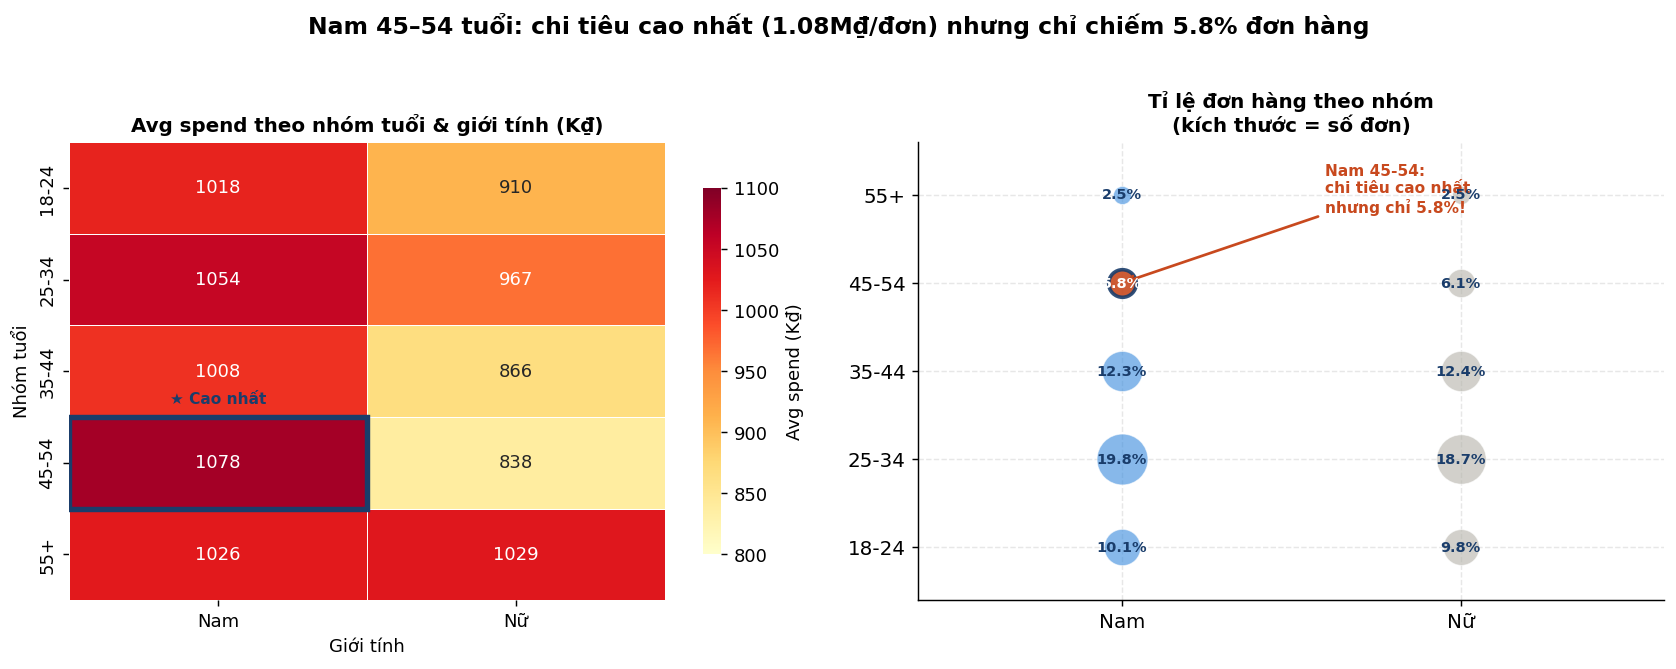


📌 Kết luận:
Nam 45-54: avg spend = 1078K₫ · 467 đơn = 5.8% tổng đơn hàng
Nhóm khách giá trị cao nhất đang bị thiếu phục vụ — cơ hội tăng revenue mà không tăng chi phí thu hút khách mới.


In [ ]:
# --- Tính dữ liệu ---
s8_avg = df.groupby(['age_group', 'gender'])['net_value'].mean().unstack()
s8_cnt = df.groupby(['age_group', 'gender'])['order_id'].count().unstack()

# Thứ tự nhóm tuổi
age_order = ['18-24', '25-34', '35-44', '45-54', '55+']
s8_avg = s8_avg.loc[age_order]
s8_cnt = s8_cnt.loc[age_order]

# --- Subplot: Heatmap avg spend + Dot plot số đơn ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Heatmap: avg spend ---
ax1 = axes[0]
heatmap = sns.heatmap(
    s8_avg / 1000,
    annot=True, fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax1,
    cbar_kws={'label': 'Avg spend (K₫)', 'shrink': 0.8},
    vmin=800, vmax=1100
)

# Highlight ô cao nhất (Nam 45-54)
max_row = age_order.index('45-54')
max_col = list(s8_avg.columns).index('Nam')
ax1.add_patch(plt.Rectangle((max_col, max_row), 1, 1,
                              fill=False, edgecolor=NAVY, lw=3, zorder=5))
ax1.text(max_col + 0.5, max_row - 0.15, '★ Cao nhất',
         ha='center', fontsize=8.5, color=NAVY, fontweight='bold')

ax1.set_title('Avg spend theo nhóm tuổi & giới tính (K₫)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Giới tính')
ax1.set_ylabel('Nhóm tuổi')

# --- Bubble chart: số đơn hàng ---
ax2 = axes[1]
x_pos = {'Nam': 0, 'Nữ': 1}
y_pos = {age: i for i, age in enumerate(age_order)}

for gender in ['Nam', 'Nữ']:
    for age in age_order:
        count = s8_cnt.loc[age, gender]
        avg   = s8_avg.loc[age, gender]
        is_max = (age == '45-54' and gender == 'Nam')
        color  = RED if is_max else (BLUE if gender == 'Nam' else GRAY)
        alpha  = 0.9 if is_max else 0.6
        ax2.scatter(x_pos[gender], y_pos[age],
                    s=count * 0.5,
                    color=color, alpha=alpha,
                    edgecolors=NAVY if is_max else 'white',
                    linewidths=2 if is_max else 0.5,
                    zorder=3)
        pct = count / df.shape[0] * 100
        ax2.text(x_pos[gender], y_pos[age],
                 f'{pct:.1f}%',
                 ha='center', va='center',
                 fontsize=8, color='white' if is_max else NAVY,
                 fontweight='bold', zorder=4)

# Annotation nhóm bị bỏ qua
ax2.annotate('Nam 45-54:\nchi tiêu cao nhất\nnhưng chỉ 5.8%!',
             xy=(x_pos['Nam'], y_pos['45-54']),
             xytext=(0.6, 3.8),
             arrowprops=dict(arrowstyle='->', color=RED, lw=1.5),
             fontsize=8.5, color=RED, fontweight='bold')

ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Nam', 'Nữ'], fontsize=11)
ax2.set_yticks(list(y_pos.values()))
ax2.set_yticklabels(list(y_pos.keys()), fontsize=11)
ax2.set_title('Tỉ lệ đơn hàng theo nhóm\n(kích thước = số đơn)', fontsize=11, fontweight='bold')
ax2.set_xlim(-0.6, 1.6)
ax2.set_ylim(-0.6, 4.6)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Nam 45–54 tuổi: chi tiêu cao nhất (1.08M₫/đơn) nhưng chỉ chiếm 5.8% đơn hàng',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('slide4_s8_age_gender_heatmap.png', bbox_inches='tight')
plt.show()

print('\n Kết luận:')
max_spend = s8_avg.loc['45-54', 'Nam']
max_count = s8_cnt.loc['45-54', 'Nam']
print(f'Nam 45-54: avg spend = {max_spend/1000:.0f}K₫ · {max_count} đơn = {max_count/df.shape[0]*100:.1f}% tổng đơn hàng')
print('Nhóm khách giá trị cao nhất đang bị thiếu phục vụ — cơ hội tăng revenue mà không tăng chi phí thu hút khách mới.')

---
## Slide 5 · Khuyến nghị — 3 cải tiến ưu tiên cho 2024

In [1]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

# Tiêu đề
ax.text(0.5, 0.97, '3 cải tiến ưu tiên cho 2024',
        ha='center', va='top', fontsize=16, fontweight='bold',
        color=NAVY, transform=ax.transAxes)
ax.text(0.5, 0.90, 'Dựa trên phân tích 8.000 đơn hàng Vietnam E-commerce 2023',
        ha='center', va='top', fontsize=10, color='gray',
        transform=ax.transAxes)

recs = [
    {
        'num': '01',
        'title': 'Cam kết SLA giao hàng ≤3 ngày toàn quốc',
        'detail': 'Rating giảm từ 4.3 → 3.7 khi giao từ ngày 5.\nƯu tiên đầu tư kho trung chuyển Miền Trung —\ncao nhất về đơn giá (1.03M) nhưng chậm nhất (3.49 ngày).',
        'source': 'Căn cứ: Slide 1 (S6) + Slide 2 (S4)',
        'color': NAVY
    },
    {
        'num': '02',
        'title': 'Tối ưu UX Web để tăng avg order và volume',
        'detail': 'Web có avg order cao hơn App 8.7% (1.055M vs 971K)\nnhưng chỉ chiếm 18% đơn. Cải thiện checkout Web,\ngợi ý sản phẩm cao cấp — nhắm nhóm 35–54 tuổi.',
        'source': 'Căn cứ: Slide 3 (S7) + Slide 4 (S8)',
        'color': GREEN
    },
    {
        'num': '03',
        'title': 'Chiến dịch targeting nhóm Nam 45–54 tuổi',
        'detail': 'Avg spend 1.08M — cao nhất toàn sàn — nhưng chỉ 5.8% đơn.\nEmail remarketing + quảng cáo Web + sản phẩm cao cấp\ncó thể tăng revenue mà không cần tăng lượng khách mới.',
        'source': 'Căn cứ: Slide 4 (S8)',
        'color': RED
    }
]

y_positions = [0.70, 0.44, 0.18]

for rec, y in zip(recs, y_positions):
    # Số thứ tự lớn
    ax.text(0.03, y, rec['num'],
            ha='left', va='top', fontsize=28, fontweight='bold',
            color=rec['color'], alpha=0.25, transform=ax.transAxes)
    # Tiêu đề khuyến nghị
    ax.text(0.10, y, rec['title'],
            ha='left', va='top', fontsize=12, fontweight='bold',
            color=rec['color'], transform=ax.transAxes)
    # Chi tiết
    ax.text(0.10, y - 0.075, rec['detail'],
            ha='left', va='top', fontsize=9.5, color='#444',
            transform=ax.transAxes, linespacing=1.6)
    # Nguồn
    ax.text(0.10, y - 0.185, rec['source'],
            ha='left', va='top', fontsize=8.5, color=GRAY,
            style='italic', transform=ax.transAxes)
    # Divider
    if y != y_positions[-1]:
        ax.plot([0.08, 0.96], [y - 0.225, y - 0.225],
                color=GRAY, alpha=0.3, linewidth=0.8,
                transform=ax.transAxes)

plt.tight_layout()
plt.savefig('slide5_recommendations.png', bbox_inches='tight', dpi=130)
plt.show()
print('Story Deck hoàn chỉnh! 5 slides đã được lưu.')

NameError: name 'plt' is not defined

---
## Narrative Summary

**Câu chuyện dữ liệu cho CEO Operations:**

1. **Giao hàng là vấn đề số 1** (S6): Chỉ cần trễ từ ngày 4, khách hàng đã cảm nhận được — rating giảm từ 4.3 xuống 3.7. Ngưỡng cam kết an toàn là ≤3 ngày.

2. **Miền Trung là điểm nóng** (S4): Đây là vùng có đơn giá cao nhất (1.03M) nhưng lại đang nhận dịch vụ giao hàng kém nhất (3.49 ngày). Đầu tư logistics ở đây có ROI cao nhất.

3. **Hai kênh, hai chiến lược** (S7): App = volume machine (75% đơn hàng), Web = premium channel (avg order cao hơn 8.7%). Không nên chọn một — cần tối ưu riêng cho từng kênh.

4. **Khách hàng vàng đang bị bỏ qua** (S8): Nam 45-54 chi tiêu 1.08M/đơn — cao nhất — nhưng chỉ chiếm 5.8% đơn hàng. Đây là phân khúc có thể tăng revenue ngay mà không cần tăng chi phí thu hút.

5. **3 hành động cụ thể**: SLA ≤3 ngày + Đầu tư logistics Miền Trung + Targeting nhóm 45-54 Nam qua Web.